<a href="https://colab.research.google.com/github/NgocKhanhHoang/insurance-premium-prediction/blob/main/Insurance_Premium_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/insurance.csv')

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
#Check categorical or binary
df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
df.sex.value_counts()

,count
sex,
male,676
female,662


In [ ]:
df.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


*   Turn sex, smoker to 0,1
*   region to multiple features: one hot coding - take categories and turn into features (binary: T/F)





In [ ]:
# Turn sex, smoker to binary
df['sex']=df['sex'].apply(lambda x: 1 if x=='female' else 0)
df['smoker']=df['smoker'].apply(lambda x: 1 if x=='yes' else 0)
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [ ]:
# Turn region (categorical) to binary; dtype int to switch from TF to 0,1
pd.get_dummies(df['region'], dtype=int)

,northeast,northwest,southeast,southwest
0,0,0,0,1
1,0,0,1,0
2,0,0,1,0
3,0,1,0,0
4,0,1,0,0
...,...,...,...,...
1333,0,1,0,0
1334,1,0,0,0
1335,0,0,1,0
1336,0,0,0,1


In [ ]:
#Join to dataframe and drop region column
#Axis=0:row, axis=1: column
df = df.join(pd.get_dummies(df['region'], dtype=int)).drop('region', axis=1)


In [ ]:
df

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,1,31.920,0,0,2205.98080,1,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,0,1


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'charges'}>],
       [<Axes: title={'center': 'northeast'}>,
        <Axes: title={'center': 'northwest'}>,
        <Axes: title={'center': 'southeast'}>],
       [<Axes: title={'center': 'southwest'}>, <Axes: >, <Axes: >]],
      dtype=object)

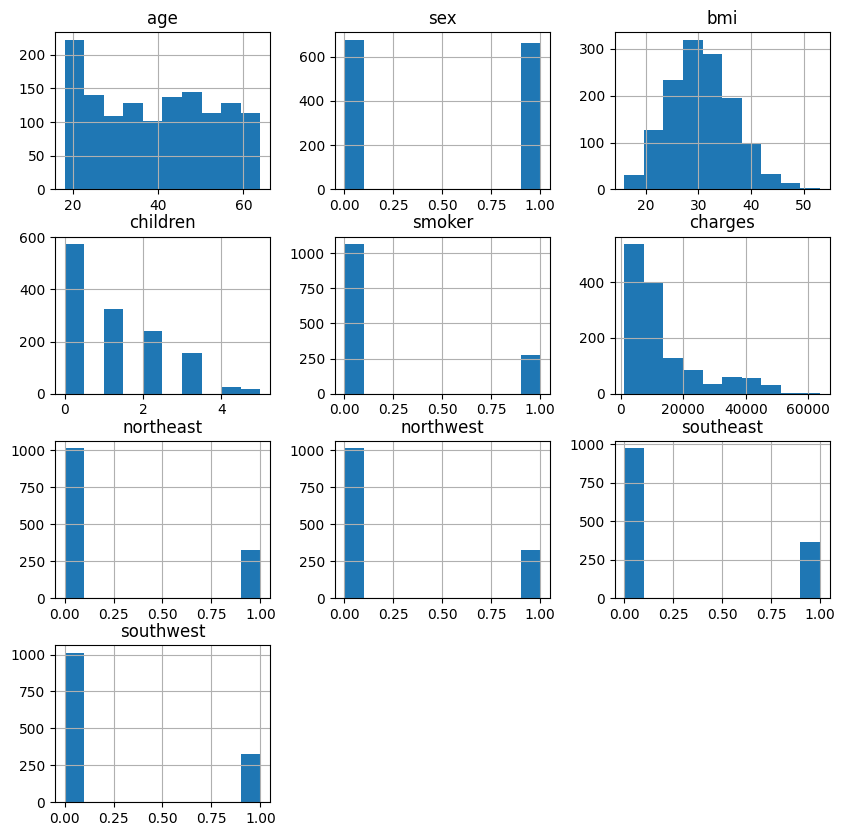

In [ ]:
df.hist(figsize=(10,10))


In [ ]:
# Check if there is any missing value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1338 non-null   int64  
 1   sex        1338 non-null   int64  
 2   bmi        1338 non-null   float64
 3   children   1338 non-null   int64  
 4   smoker     1338 non-null   int64  
 5   charges    1338 non-null   float64
 6   northeast  1338 non-null   int64  
 7   northwest  1338 non-null   int64  
 8   southeast  1338 non-null   int64  
 9   southwest  1338 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 104.7 KB


In [ ]:
df.corr()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008,0.002475,-0.000407,-0.011642,0.010016
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292,0.002425,0.011156,-0.017117,0.004184
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341,-0.138156,-0.135996,0.270025,-0.006205
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998,-0.022808,0.024806,-0.023066,0.021914
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251,0.002811,-0.036945,0.068498,-0.036945
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000,0.006349,-0.039905,0.073982,-0.043210
northeast,0.002475,0.002425,-0.138156,-0.022808,0.002811,0.006349,1.000000,-0.320177,-0.345561,-0.320177
northwest,-0.000407,0.011156,-0.135996,0.024806,-0.036945,-0.039905,-0.320177,1.000000,-0.346265,-0.320829
southeast,-0.011642,-0.017117,0.270025,-0.023066,0.068498,0.073982,-0.345561,-0.346265,1.000000,-0.346265
southwest,0.010016,0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320177,-0.320829,-0.346265,1.000000


<Axes: >

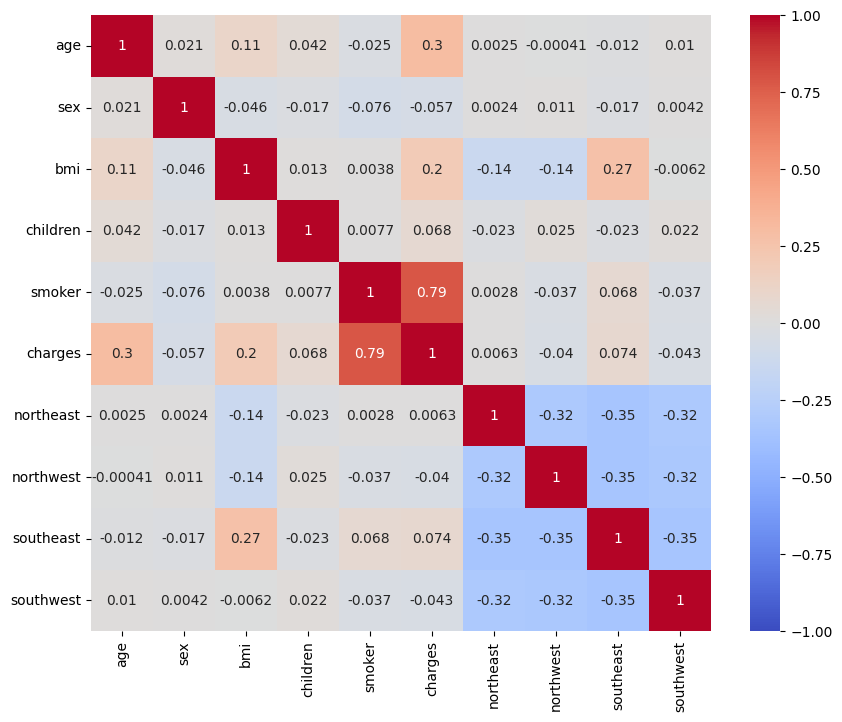

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm',vmin=-1, vmax=1)

# annot (annotation): True if you want numbers appear on the color
# cmap: color scheme
# vmin, vmax: min and max value for color scale
# red: positive correlation, blue: negative correlation (mutually exclusive)


* .79: charges-smoker, almost perfect positive relationship

* Correlation ≠ feature importance. Random Forest shows which features truly matter for predictions.


In [ ]:
from sklearn.model_selection import train_test_split #a tools for split data to training and testing set
# Take X and Y data => split to training set and testing set
from sklearn.ensemble import RandomForestRegressor #Bring Random Forest - model can predict number (regression - different from classification for categories)

from sklearn.metrics import mean_squared_error, mean_absolute_error # Brings in tools to measure how good your predictions are.
# mean_squared_error = average squared difference between predicted and actual values
# mean_absolute_error = average absolute difference

X = df.drop("charges", axis=1) #inputs, everything except charges
y = df["charges"] #output, "charges"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #20% of dataset will be used for evaluation, 80% for training

In [ ]:
model = RandomForestRegressor(n_jobs=-1) #n_jobs=-1: use all available CPU cores on the system to train the model
model.fit(X_train, y_train)
#fit method that starts the training process with X_train is input variables and y_train is target/output variable
#telling the model to learn the relationship between the features and the target variables

RandomForestRegressor(n_jobs=-1)

In [ ]:
model.score(X_test, y_test) #R-squared score
#Evaluate how well your trained model performs on the unseen data (from 0 to 1, with 1 the best)
#Not accuracy in classification task as it appropriate for regression (numerical)

0.8000288621346422

In [ ]:
from sklearn.metrics import root_mean_squared_error

y_pred=model.predict(X_test)
#how the predicting value different from actual result:
rmse = root_mean_squared_error(y_test, y_pred)


In [ ]:
rmse

5310.22298453902

In [ ]:
df.charges.std()
# good rmse as it is much smaller than std

12110.011236693994

In [ ]:
y_test.std()

11897.093249235446

In [ ]:
df.charges.median()

9382.033

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mae

3005.56954234919

Text(0.5, 1.0, 'Charges vs Predicted charges')

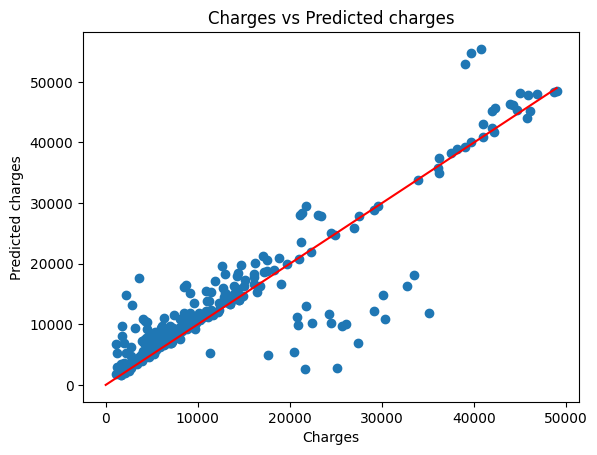

In [ ]:
import numpy as np

plt.scatter(y_test, y_pred)
# draw the best fit line
plt.plot(np.linspace(0,max(y_test)), np.linspace(0,max(y_test)), color='red')
plt.xlabel('Charges')
plt.ylabel('Predicted charges')
plt.title('Charges vs Predicted charges')

* we have some points off from the best fit line -> actual values is not predicted correctly
* most points are being predicted well.

Can we get better?

In [ ]:
feature_importances = sorted(zip(model.feature_names_in_, model.feature_importances_), key=lambda x:x[1],reverse=True)
# Creates a ranked list of your features, showing which ones are most important to your model - from most to least important
# feature_names_in_: a list of all the input feature names
# feature_importances_: how important each feature is to the model
# zip(...,...): pairs up tems from each iterable based on their position (index)
# sorted(iterable, key=lambda x: x[1], reverse=True): sorts the list based on the second item in each pair (x[1] - the importance value), from largest to smallest (because of reverse=True)

Text(0.5, 1.0, 'Feature Importances')

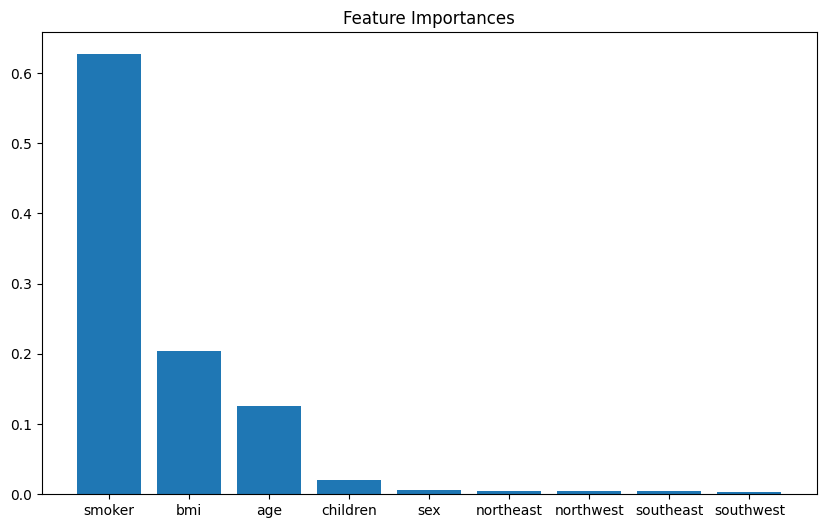

In [ ]:
plt.figure(figsize=(10,6))
plt.bar([x[0] for x in feature_importances], [x[1] for x in feature_importances])
plt.title("Feature Importances")

# **Hyperparameter tuning**

In [ ]:
# Hyperparameter tuning: Find the hyperparameter combination that makes your model perform best (accurate, fast, generalizes well)
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [None, 2, 5],        # How deep each decision tree can grow
    'min_samples_split': [2, 4, 6, 8], # The minimum number of samples needed to make a new branch
    'min_samples_leaf': [1, 2, 4, 6]  # Minimum samples at the end of a branch
}

model = RandomForestRegressor(n_jobs=-1)

grid_search = GridSearchCV(model, param_grid = param_grid, cv=5)
# train the model using each combination of hyperparameters
# test them using 5-fold cross-validation (cv=5), train on 4 parts, test on 1
# param_grid=param_grid means:Use the dictionary I made as the set of values to search over.


In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'max_depth': [None, 2, 5],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 4, 6, 8]})

In [ ]:
grid_search.best_params_
# only gives you the number

{'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 8}

In [ ]:
model = grid_search.best_estimator_
# use best parameters to train the model

In [ ]:
model

RandomForestRegressor(max_depth=5, min_samples_leaf=6, min_samples_split=8,
                      n_jobs=-1)

In [ ]:
model.score(X_test, y_test)

# We have to use the test dataset (X_test, y_test)
# so hyperparameters aren’t chosen based on the test data and the results stay unbiased.

0.8443894886958259

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
rmse = root_mean_squared_error(y_test, y_pred)

In [ ]:
rmse

4684.341666435664

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
mae

2562.6531433793266

Text(0.5, 1.0, 'Charges vs Predicted charges')

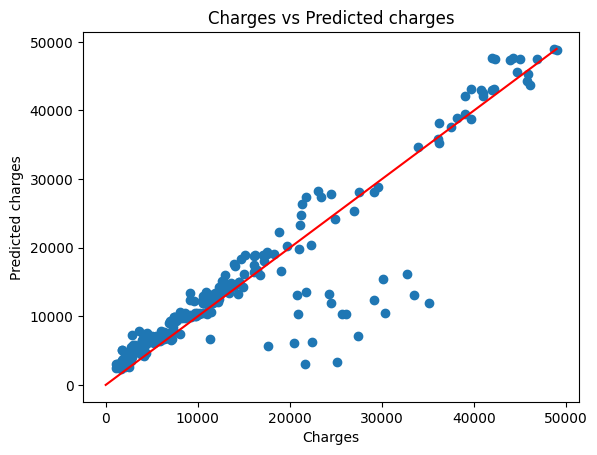

In [ ]:
import numpy as np

plt.scatter(y_test, y_pred)
# draw the best fit line
plt.plot(np.linspace(0,max(y_test)), np.linspace(0,max(y_test)), color='red')
plt.xlabel('Charges')
plt.ylabel('Predicted charges')
plt.title('Charges vs Predicted charges')

# **Adding metrics of hyperparameter tuning**

In [ ]:
# Hyperparameter tuning: Find the hyperparameter combination that makes your model perform best (accurate, fast, generalizes well)
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [None, 2, 5, 8, 13],        # How deep each decision tree can grow
    'min_samples_split': [2, 4, 6, 8], # The minimum number of samples needed to make a new branch
    'min_samples_leaf': [1, 2, 4, 6]  # Minimum samples at the end of a branch
}

model = RandomForestRegressor(n_jobs=-1)

grid_search = GridSearchCV(model, param_grid = param_grid, cv=5, scoring = "neg_mean_absolute_error")
# train the model using each combination of hyperparameters
# test them using 5-fold cross-validation (cv=5), train on 4 parts, test on 1
# param_grid=param_grid means:Use the dictionary I made as the set of values to search over.


In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'max_depth': [None, 2, 5, 8, 13],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 4, 6, 8]},
             scoring='neg_mean_absolute_error')

In [ ]:
grid_search.best_params_
# only gives you the number

{'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 6}

In [ ]:
model = grid_search.best_estimator_
# use best parameters to train the model

In [ ]:
model

RandomForestRegressor(max_depth=8, min_samples_leaf=6, min_samples_split=6,
                      n_jobs=-1)

In [ ]:
model.score(X_test, y_test)

# We have to use the test dataset (X_test, y_test)
# so hyperparameters aren’t chosen based on the test data and the results stay unbiased.

0.840738189748397

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
rmse = root_mean_squared_error(y_test, y_pred)

In [ ]:
rmse

4738.980516504063

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

In [ ]:
mae

2581.489501984843

Text(0.5, 1.0, 'Charges vs Predicted charges')

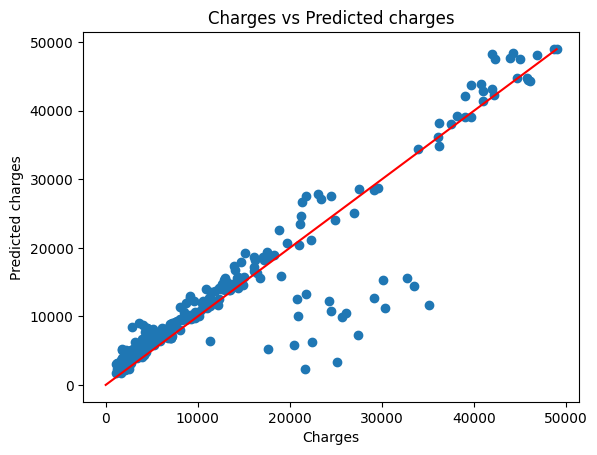

In [ ]:
import numpy as np

plt.scatter(y_test, y_pred)
# draw the best fit line
plt.plot(np.linspace(0,max(y_test)), np.linspace(0,max(y_test)), color='red')
plt.xlabel('Charges')
plt.ylabel('Predicted charges')
plt.title('Charges vs Predicted charges')

In [ ]:
smoker_means = df.groupby("smoker")["charges"].mean()
smoker_rato = smoker_means[1]/smoker_means[0]
smoker_rato

np.float64(3.800001458298319)